# Phase 1 — Data Exploration
Goal: understand the dataset before cleaning it.

In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/ecommerce_dataset.csv')
print('Shape:', df.shape)
df.head(3)

Shape: (1000, 21)


,product_id,external_id,title,brand,category,subcategory,url,source,price_current,price_original,...,discount_pct,has_discount,rating_score,reviews_count,availability,description,images_count,first_image,tags,scraped_at
0,9efc81ac-b34e-487a-b7a1-6fe9c9d7920b,9749998221059,Huawei Tablet Pro,Huawei,Electronics,NaN,https://www.amazon.com/product/huawei-tablet-p...,amazon,1487.49,NaN,...,NaN,False,4.8,177,in_stock,Crafted with attention to detail and backed by...,1,https://cdn.amazon.example/img/9749998221059.jpg,amazon|electronics,2026-03-21T05:42:24.094706
1,6c26ff34-72d3-45d8-aa01-71e58253e3c6,8979986990555,Adidas Portable Hoodie Plus,Adidas,Fashion,NaN,https://www.amazon.com/product/adidas-portable...,amazon,1125.26,1575.36,...,28.6,True,3.7,665,out_of_stock,A versatile product suitable for a wide range ...,1,https://cdn.amazon.example/img/8979986990555.jpg,amazon|fashion,2026-03-27T11:23:36.862451
2,b271d64f-790b-4561-af51-5ff5d7b0a132,9473792172229,Calvin Klein Sneakers Pro,Calvin,Fashion,NaN,https://www.amazon.com/product/calvin-klein-sn...,amazon,1357.13,NaN,...,NaN,False,3.9,379,out_of_stock,Thoughtfully designed to deliver value without...,1,https://cdn.amazon.example/img/9473792172229.jpg,amazon|fashion,2026-03-24T17:44:49.598673


In [2]:
# Task 1.2.2 — Column names, data types, fill rates
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notna().sum(),
    'fill_%': (df.notna().mean() * 100).round(1)
})
summary

,dtype,non_null,fill_%
product_id,str,1000,100.0
external_id,int64,1000,100.0
title,str,1000,100.0
brand,str,1000,100.0
category,str,1000,100.0
subcategory,float64,0,0.0
url,str,1000,100.0
source,str,1000,100.0
price_current,float64,1000,100.0
price_original,float64,284,28.4


In [3]:
# Task 1.2.3 — Categories and sources
print('=== Categories ===')
print(df['category'].value_counts())
print('\n=== Sources ===')
print(df['source'].value_counts())

=== Categories ===
category
Beauty         135
Sports         127
Food           121
Home           120
Fashion        115
Electronics    113
Toys            80
Automotive      78
Garden          57
Books           54
Name: count, dtype: int64

=== Sources ===
source
amazon        200
noon          200
aliexpress    200
jumia         200
ebay          200
Name: count, dtype: int64


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 8.3 MB/s eta 0:00:00a 0:00:01m
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 8.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 7.4 MB/s eta 0:00:00a 0:00:01m
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
count     1000.000000
mean      6268.795440
std      11067.654034
min          1.080000
25%        438.307500
50%       1723.325000
75%       5227.932500
max      49720.600000
Name: price_current, dtype: float64


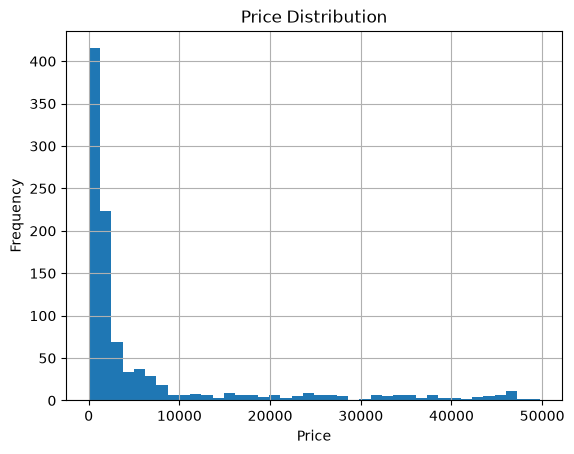

In [6]:
%pip install matplotlib
import matplotlib.pyplot as plt
# Task 1.2.4 — Price distribution
print(df['price_current'].describe())
df['price_current'].hist(bins=40)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Price Distribution')
plt.show()

count    796.000000
mean       3.761558
std        0.713080
min        2.500000
25%        3.200000
50%        3.800000
75%        4.400000
max        5.000000
Name: rating_score, dtype: float64


<Axes: >

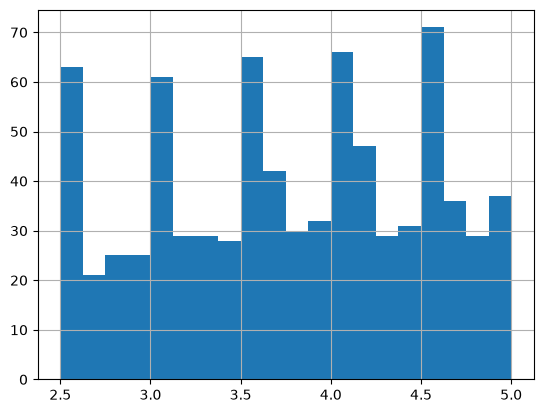

In [7]:
# Task 1.2.3 — Rating distribution
print(df['rating_score'].describe())
df['rating_score'].hist(bins=20)

In [8]:
# Inspect a few sample rows
for _, row in df.sample(3, random_state=42).iterrows():
    print('Title   :', row['title'])
    print('Brand   :', row['brand'])
    print('Category:', row['category'])
    print('Price   :', row['price_current'])
    print('Rating  :', row['rating_score'])
    print('Desc    :', str(row['description'])[:200])
    print('-' * 60)

Title   : NYX Perfume Plus
Brand   : NYX
Category: Beauty
Price   : 118.41
Rating  : nan
Desc    : Engineered for performance with precision components and reliable construction.
------------------------------------------------------------
Title   : Cadbury Ultra Protein Bar Lite
Brand   : Cadbury
Category: Food
Price   : 9363.34
Rating  : 3.9
Desc    : Engineered for performance with precision components and reliable construction.
------------------------------------------------------------
Title   : Puma Yoga Mat Pro
Brand   : Puma
Category: Sports
Price   : 20430.93
Rating  : 3.6
Desc    : Built for everyday use with durable materials and ergonomic design.
------------------------------------------------------------
